In [ ]:
# Cell 1: Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image as image

# Set display size for matplotlib
plt.rcParams["figure.figsize"] = (10, 6)



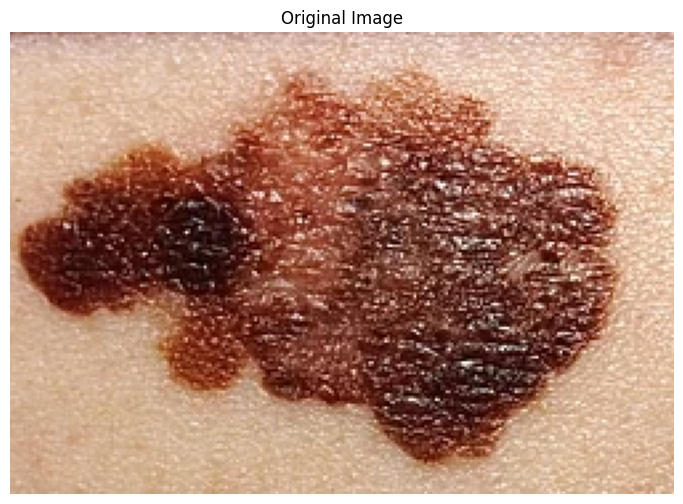

In [ ]:
# Cell 2: Load and display the original image
image_path = r"D:\Final Year Project\ImageProcessing\Images\Melanoma_1.jpg"  # Replace with your image path
img = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB
plt.title("Original Image")
plt.axis('off')
plt.show()

cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


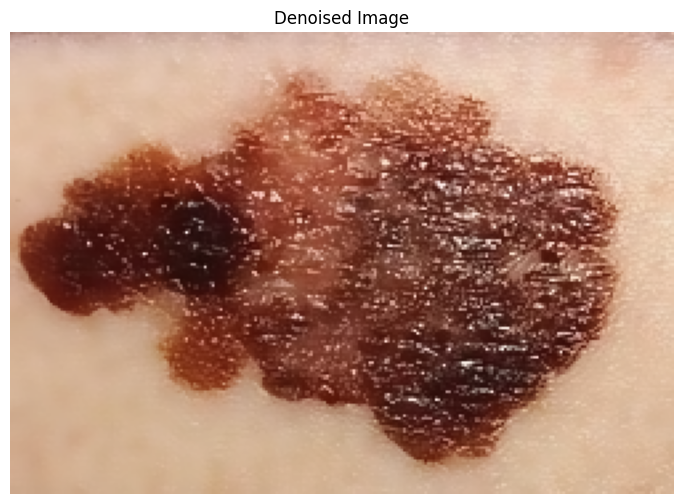

In [ ]:
# Cell 3: Denoise using bilateral filter
denoised = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
plt.title("Denoised Image")
plt.axis('off')
plt.show()



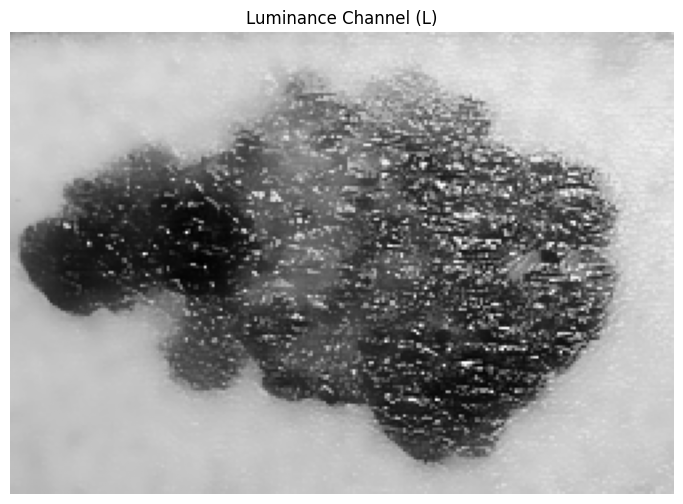

In [ ]:
# Cell 4: Convert to LAB color space and split channels
lab_img = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
L, A, B = cv2.split(lab_img)

# Display L channel (luminance)
plt.imshow(L, cmap='gray')
plt.title("Luminance Channel (L)")
plt.axis('off')
plt.show()


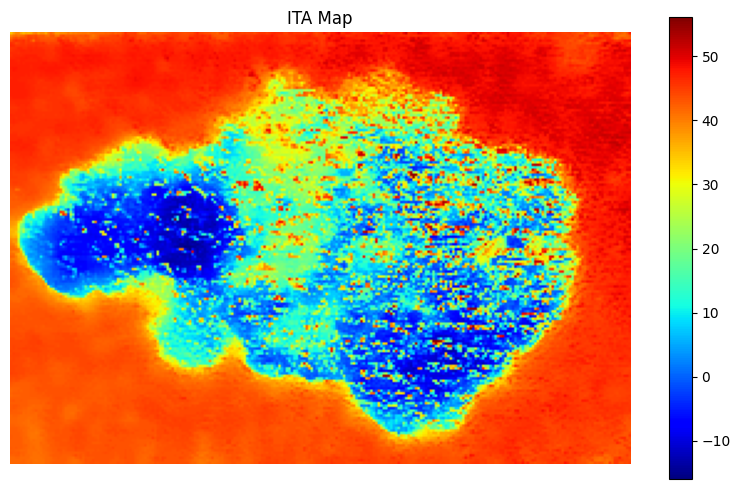

In [ ]:
# Cell 5: Enhance L channel using CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
L_enhanced = clahe.apply(L)

plt.imshow(L_enhanced, cmap='gray')
plt.title("Enhanced Luminance (CLAHE)")
plt.axis('off')
plt.show()


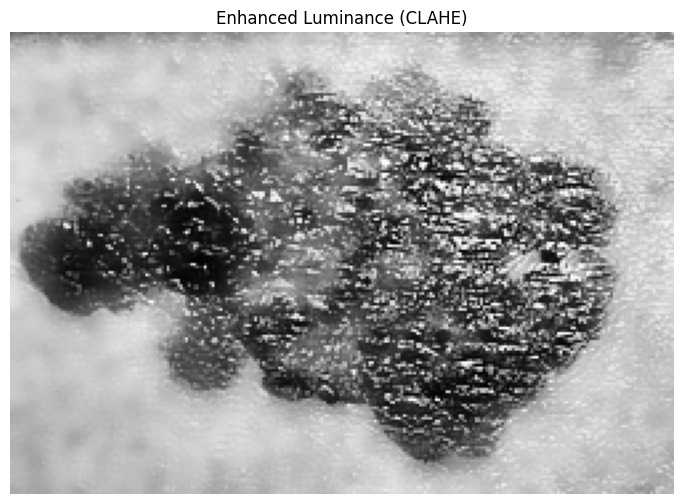

In [ ]:
# Cell 6: Enhance L channel using CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
L_enhanced = clahe.apply(L)

plt.imshow(L_enhanced, cmap='gray')
plt.title("Enhanced Luminance (CLAHE)")
plt.axis('off')
plt.show()




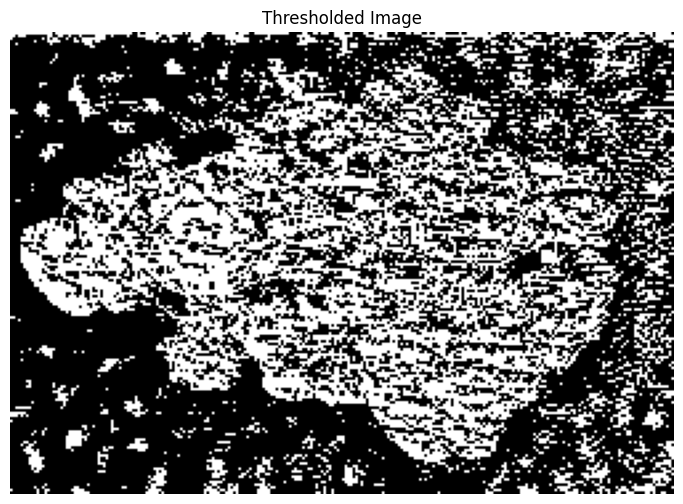

In [ ]:
# Cell 7: Threshold enhanced L channel
thresh = cv2.adaptiveThreshold(
    L_enhanced, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21, 5
)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()


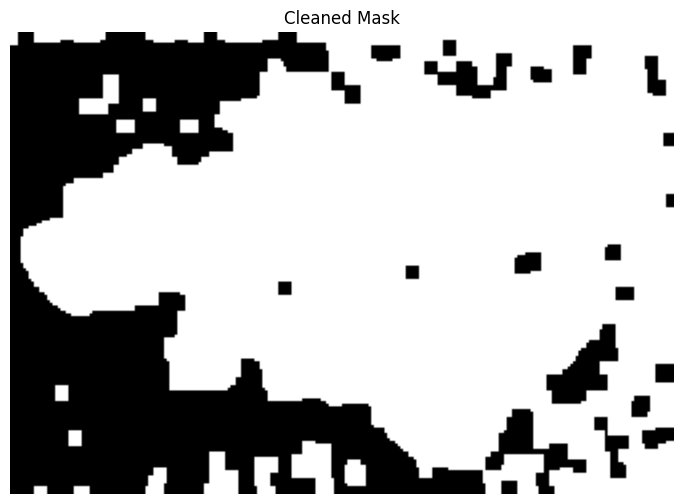

In [ ]:
#Cell 8: Morphological cleanup
kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

plt.imshow(mask_clean, cmap='gray')
plt.title("Cleaned Mask")
plt.axis('off')
plt.show()



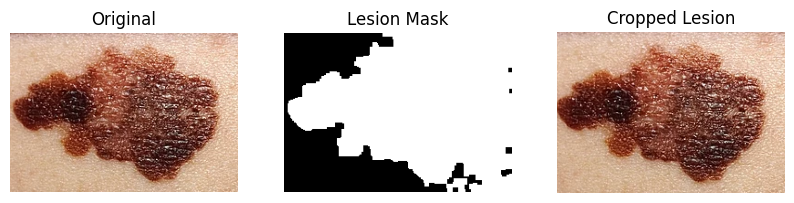

In [ ]:
#Cell 9: Find contours and extract lesion
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("No lesion detected!")
else:
    # Largest contour assumed to be lesion
    largest_contour = max(contours, key=cv2.contourArea)
    
    lesion_mask = np.zeros_like(L)
    cv2.drawContours(lesion_mask, [largest_contour], -1, 255, -1)
    
    x, y, w, h = cv2.boundingRect(largest_contour)
    lesion_crop = img[y:y+h, x:x+w]
    
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(lesion_mask, cmap='gray')
    plt.title("Lesion Mask")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(lesion_crop, cv2.COLOR_BGR2RGB)
               )
    plt.title("Cropped Lesion")
    plt.axis('off')
    
    plt.show()


In [ ]:
# Cell 10: Resize and normalize lesion for model input
if len(contours) > 0:
    lesion_resized = cv2.resize(lesion_crop, (224, 224))
    lesion_normalized = lesion_resized / 255.0
    print("Lesion ready for model input:", lesion_normalized.shape)



Lesion ready for model input: (224, 224, 3)


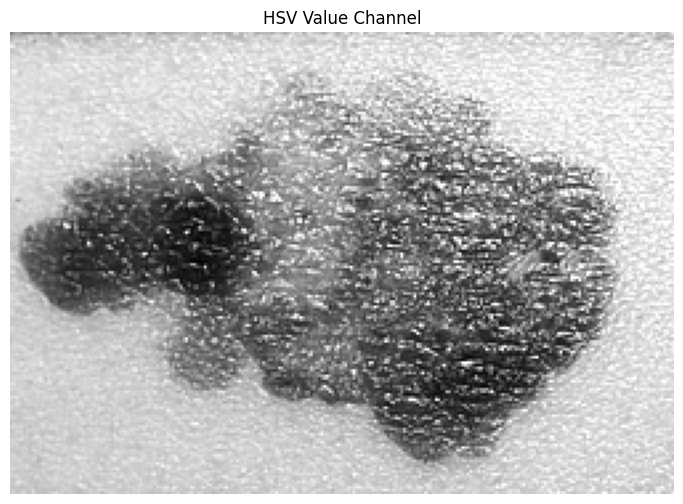

In [ ]:

# Cell 11:Convert to HSV to use the Value channel
hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv_image)

# Display Value channel (brightness)
plt.imshow(V, cmap='gray')
plt.title("HSV Value Channel")
plt.axis('off')
plt.show()


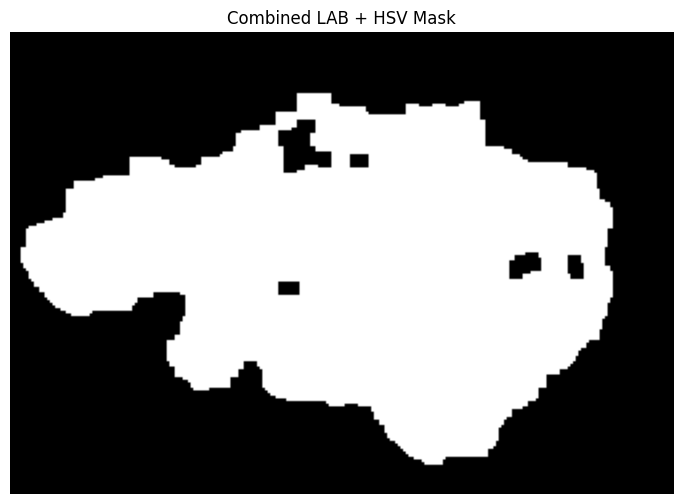

In [ ]:
#Cell 12: Combine LAB and HSV for thresholding
_, lab_thresh = cv2.threshold(L_enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Threshold V channel to remove hair/background (hair usually darker but low saturation)
_, v_thresh = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
v_thresh_inv = cv2.bitwise_not(v_thresh)  # invert so lesion stays white

# Combine LAB and HSV masks
combined_mask = cv2.bitwise_and(lab_thresh, v_thresh_inv)

# Morphological cleanup
combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)

plt.imshow(combined_mask, cmap='gray')
plt.title("Combined LAB + HSV Mask")
plt.axis('off')
plt.show()


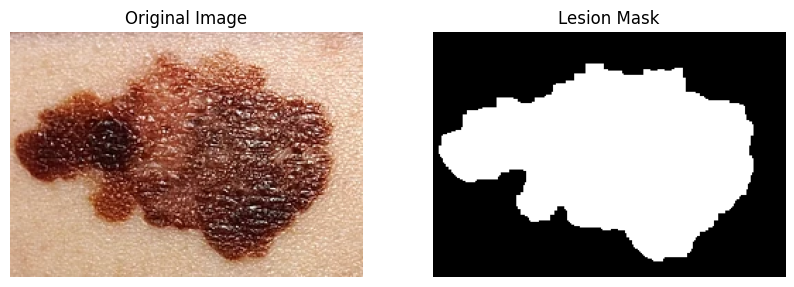

In [101]:
# Cell 13: Find contours and show lesion mask (combined)
contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("No lesion detected!")
else:
    largest_contour = max(contours, key=cv2.contourArea)
    
    lesion_mask = np.zeros_like(L)
    cv2.drawContours(lesion_mask, [largest_contour], -1, 255, -1)

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(lesion_mask, cmap='gray')
    plt.title("Lesion Mask")
    plt.axis('off')
    
    
    plt.show()
